In [25]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 設定中文字體，解決中文顯示問題
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']  # 設定字體
plt.rcParams['axes.unicode_minus'] = False  # 解決負號顯示問題

In [26]:
# 1. 準備資料
# stock_id = "2330.TW" # 台積電
stock_id = "2002.TW"  # 中鋼

print(f"機器人正在回測 {stock_id} 的策略績效...")
stock = yf.Ticker(stock_id)
df = stock.history(period="3y")

機器人正在回測 2002.TW 的策略績效...


In [27]:
# 2. 計算均線
df['MA5'] = df['Close'].rolling(window=5).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()

# 取得昨天的均線 (用來比對交叉)
df['Prev_MA5'] = df['MA5'].shift(1)
df['Prev_MA20'] = df['MA20'].shift(1)

In [28]:
# --- 核心策略邏輯 ---
# 黃金交叉 (買進訊號)：今天 MA5 > MA20 且 昨天 MA5 < MA20
df['Buy_Signal'] = (df['MA5'] > df['MA20']) & (df['Prev_MA5'] < df['Prev_MA20'])

# 死亡交叉 (賣出訊號)：今天 MA5 < MA20 且 昨天 MA5 > MA20
df['Sell_Signal'] = (df['MA5'] < df['MA20']) & (df['Prev_MA5'] > df['Prev_MA20'])

In [29]:
# --- 3. 模擬交易流程 (Backtesting) ---
position = 0      # 持倉狀態 (0:空手, 1:持有)
entry_price = 0   # 進場成本
total_profit = 0  # 累積獲利 (元/股)
trade_history = [] # 交易紀錄

print("\n--- 交易紀錄明細 ---")
for index, row in df.iterrows():
    # 策略 1: 沒股票 + 看到黃金交叉 -> 買進
    if position == 0 and row['Buy_Signal']:
        position = 1
        entry_price = row['Close']
        trade_history.append((index, 'Buy', row['Close']))
        print(f"[{index.strftime('%Y-%m-%d')}] 買進 @ {row['Close']:.2f}")

    # 策略 2: 有股票 + 看到死亡交叉 -> 賣出
    elif position == 1 and row['Sell_Signal']:
        position = 0
        profit = row['Close'] - entry_price
        total_profit += profit
        trade_history.append((index, 'Sell', row['Close']))
        print(f"[{index.strftime('%Y-%m-%d')}] 賣出 @ {row['Close']:.2f} | 損益: {profit:+.2f}")

# 結算：如果你最後還持有股票，我們用最後一天的收盤價算帳
if position == 1:
    last_price = df.iloc[-1]['Close']
    profit = last_price - entry_price
    total_profit += profit
    print(f"[{df.index[-1].strftime('%Y-%m-%d')}] (庫存結算) 賣出 @ {last_price:.2f} | 損益: {profit:+.2f}")

print("-" * 30)
print(f"累積總損益: {total_profit:+.2f} 元/股")
print("-" * 30)


--- 交易紀錄明細 ---
[2023-03-22] 買進 @ 29.19
[2023-03-31] 賣出 @ 28.91 | 損益: -0.28
[2023-04-13] 買進 @ 29.43
[2023-04-18] 賣出 @ 28.72 | 損益: -0.70
[2023-05-19] 買進 @ 27.69
[2023-05-30] 賣出 @ 27.13 | 損益: -0.56
[2023-06-07] 買進 @ 27.98
[2023-06-30] 賣出 @ 27.51 | 損益: -0.47
[2023-07-21] 買進 @ 27.37
[2023-08-04] 賣出 @ 27.41 | 損益: +0.05
[2023-08-08] 買進 @ 27.36
[2023-08-09] 賣出 @ 27.27 | 損益: -0.10
[2023-09-07] 買進 @ 25.67
[2023-09-11] 賣出 @ 25.43 | 損益: -0.24
[2023-09-19] 買進 @ 25.67
[2023-09-21] 賣出 @ 25.33 | 損益: -0.34
[2023-11-06] 買進 @ 24.22
[2023-12-13] 賣出 @ 24.36 | 損益: +0.15
[2023-12-19] 買進 @ 25.81
[2024-01-10] 賣出 @ 25.04 | 損益: -0.77
[2024-02-21] 買進 @ 24.46
[2024-02-27] 賣出 @ 23.88 | 損益: -0.58
[2024-04-01] 買進 @ 23.25
[2024-04-30] 賣出 @ 24.07 | 損益: +0.82
[2024-05-03] 買進 @ 24.17
[2024-05-23] 賣出 @ 23.39 | 損益: -0.77
[2024-07-08] 買進 @ 22.76
[2024-07-11] 賣出 @ 22.33 | 損益: -0.44
[2024-07-18] 買進 @ 22.76
[2024-07-29] 賣出 @ 22.52 | 損益: -0.24
[2024-07-31] 買進 @ 22.82
[2024-08-05] 賣出 @ 21.59 | 損益: -1.23
[2024-08-28] 買進 @ 21.98


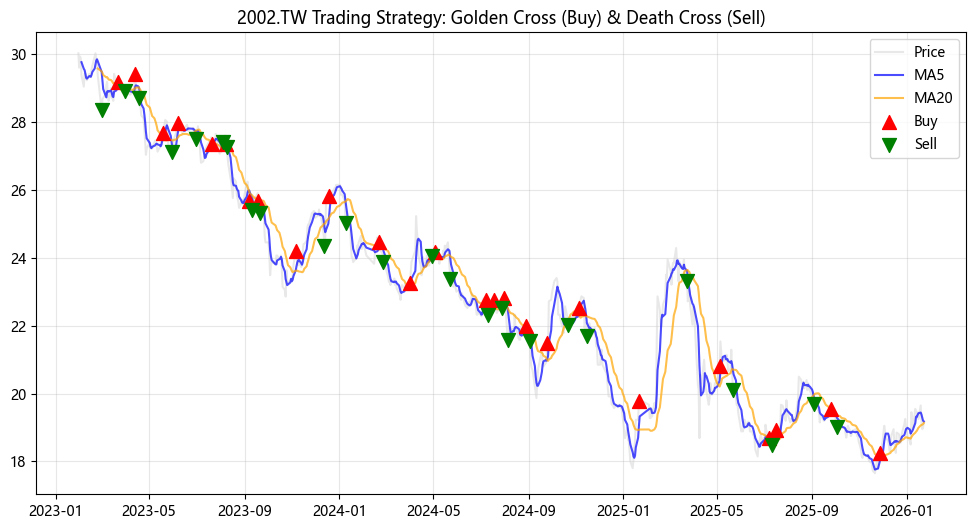

In [30]:
# --- 4. 畫圖驗收 ---
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Price', color='lightgray', alpha=0.5)
plt.plot(df.index, df['MA5'], label='MA5', color='blue', alpha=0.7)
plt.plot(df.index, df['MA20'], label='MA20', color='orange', alpha=0.7)

# 畫出買賣點
buys = df[df['Buy_Signal']]
sells = df[df['Sell_Signal']]

# 紅色向上三角形 = 買進
plt.scatter(buys.index, buys['Close'], color='red', marker='^', s=100, label='Buy', zorder=5)
# 綠色向下三角形 = 賣出
plt.scatter(sells.index, sells['Close'], color='green', marker='v', s=100, label='Sell', zorder=5)

plt.title(f'{stock_id} Trading Strategy: Golden Cross (Buy) & Death Cross (Sell)')
plt.legend()
plt.grid(True, alpha=0.3)
# plt.savefig('strategy_backtest.png')
plt.show()